# Computer Book A: The Poisson Processes

These series of codes, illustrate using python, the various exercises from the OU course M248 Analysing Data. The exercises were originally written to be carried out using Minitab statistical software but those exercises have been re-done in Python below

## Computer activity 36: Is the average rate constant?

In this activity you will investigate whether the rate at which serious earthquakes occurred remained constant over the period of observation by plotting the number of earthquakes that have occurred so far against time.

    Interval   Time  Number
0        186    186       1
1         77    263       2
2        682    945       3
3        449   1394       4
4         91   1485       5
..       ...    ...     ...
62       717  21087      63
63       506  21593      64
64       104  21697      65
65        91  21788      66
66       332  22120      67

[67 rows x 3 columns]


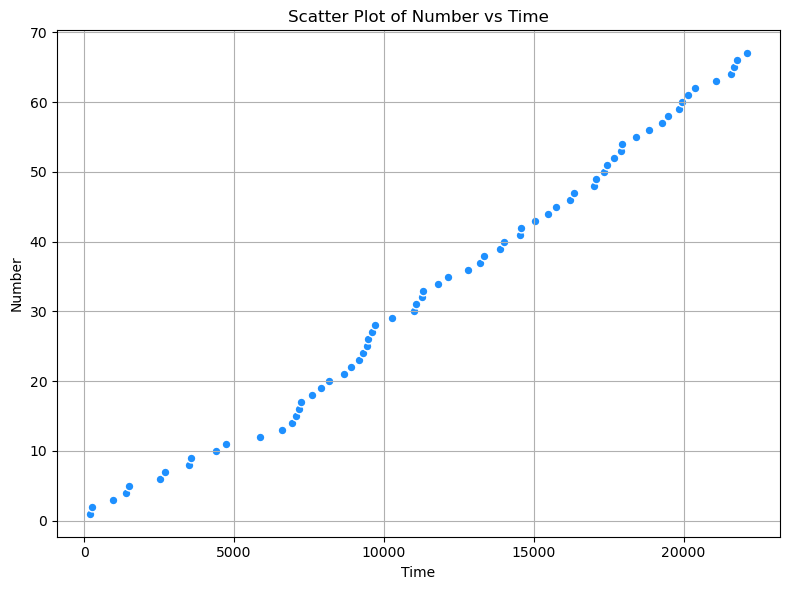

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from csv
df = pd.read_csv(r'C:\Python\OU M248 Data Analysis using Python\Data files\serious-earthquakes.csv')

# Return the first 5 rows of the dataframe
# print(df.head(5))

# Do a cumulative sum of the interval times between earthquakes into another column called Time
# running (consecutive) sum of Interval
df["Time"] = df["Interval"].cumsum()

# Do a cumulative count of the interval times between earthquakes into another column called Number
# running (consecutive) count of Interval i.e. count the number of rows and then label in a new column from 1 to number of rows
df["Number"] = range(1, len(df) + 1)

# Print the dataframe with the new added columns
print(df)

# Assign columns to X and Y variables
x_col = "Time"
y_col = "Number"

# Plot the scatter
plt.figure(figsize=(8, 6))
plt.scatter(df[x_col], df[y_col], 
            c='dodgerblue',        # marker color
            alpha=1,       # transparency
            edgecolor='w',   # marker border color
            s=40)            # marker size

# Label the axis and title
plt.title(f'Scatter Plot of {y_col} vs {x_col}')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


#### Commentary

By observation of the scatter plot it can be seen that the rate of occurance of serious earthquakes is constant over the given period i.e. all the data points lie on a fairly straight line which implies a fixed gradient.

Note: the original datasource had only column with two new columns added (Time and Number). Time is the cumulative running total of times between serious earthquakes e.g. from no earthquake to the first earthquake is 186 days and from the first to the second earthquake is 77 days so that from no earthquake to the second earthquake is 263 days. Time is the count of occurance of each serious earthquake cumulatively. 

## Computer activity 37: Waiting times

The intervals, or waiting times, between successive events in a Poisson process are exponentially distributed. In this activity, you will explore the data in serious-earthquakes to see whether an exponential model is a good one for the intervals between serious earthquakes.

a) Find the mean and standard deviation of the intervals between serious earthquakes. Check that these values are consistent with the data being observations from an exponential distribution

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from csv
df = pd.read_csv(r'C:\Python\OU M248 Data Analysis using Python\Data files\serious-earthquakes.csv')

# Return the first 5 rows of the dataframe
# print(df.head(5))

# Do a cumulative sum of the interval times between earthquakes into another column called Time
# running (consecutive) sum of Interval
df["Time"] = df["Interval"].cumsum()

# Do a cumulative count of the interval times between earthquakes into another column called Number
# running (consecutive) count of Interval i.e. count the number of rows and then label in a new column from 1 to number of rows
df["Number"] = range(1, len(df) + 1)

# Print the dataframe with the new added columns
print(df)

mean_interval = df["Interval"].mean()
std_interval = df["Interval"].std()

print("Mean of intervals between serious earthquakes: ", round(mean_interval,3))
print("Standard deviation of intertvals between serious earthquakes: ", round(std_interval,3))

    Interval   Time  Number
0        186    186       1
1         77    263       2
2        682    945       3
3        449   1394       4
4         91   1485       5
..       ...    ...     ...
62       717  21087      63
63       506  21593      64
64       104  21697      65
65        91  21788      66
66       332  22120      67

[67 rows x 3 columns]
Mean of intervals between serious earthquakes:  330.149
Standard deviation of intertvals between serious earthquakes:  254.745


#### Commentary

Note that according to the properties of an exponential distribution the standard deviation is equal to the mean.

Hence, since the mean and standard deviation of intervals between serious earthquakes are very close it is safe to assume that these values are consistant with observations from an exponential distribution.

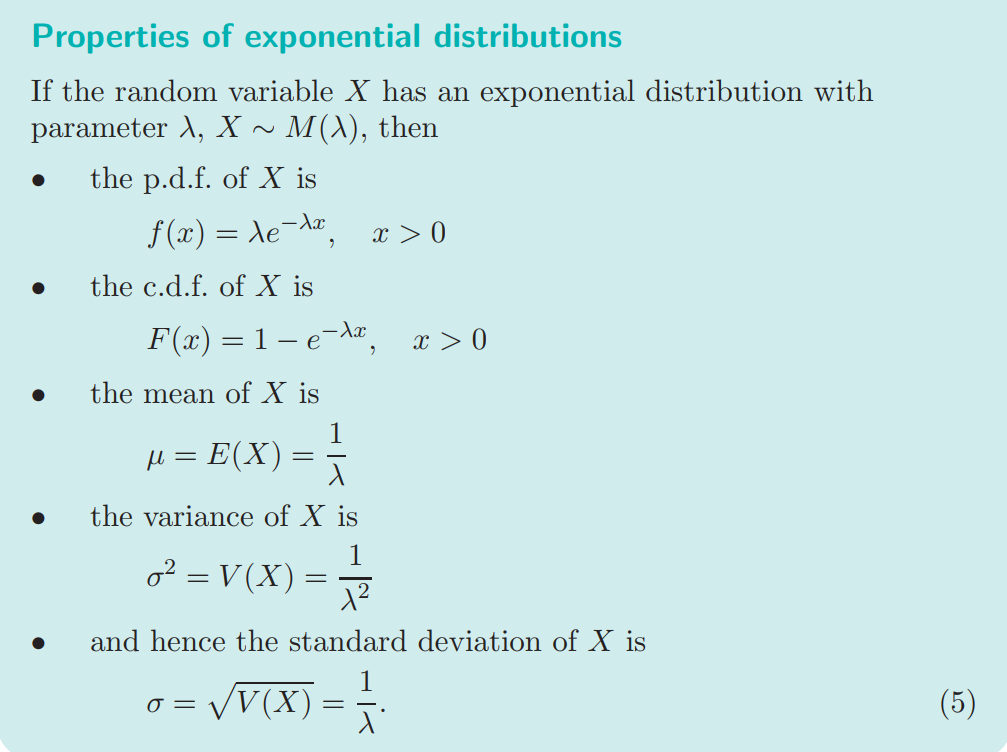

b) Obtain a historgram of the data with the following properties:
* The ticks on the horizontal axis are at the cutpoints
* The bins have a width 100
* The first bin starts at 0 and the last finishes at 1200

Is the shape of the histogram consistent with an exponential distribution being a good model for the intervals between serious earthquakes?


   Interval
0       186
1        77
2       682
3       449
4        91


Text(0, 0.5, 'Frequency')

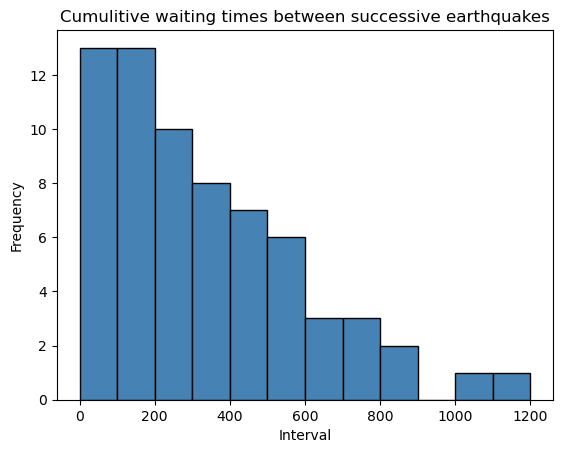

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from csv
df = pd.read_csv(r'C:\Data Analysis\OU M248 Data Analysis using Python\Data files\serious-earthquakes.csv')

print(df.head()) #return the first 5 rows of the dataframe

# Define cutpoints
cutpoints = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200]

# Plot histogram from Weight change column
plt.hist(df['Interval'], bins=cutpoints, color='steelblue', edgecolor='black', density=False) #Density=False means not to convert to unit area histog

# Add labels and a title
plt.title('Cumulitive waiting times between successive earthquakes')
plt.xlabel('Interval')
plt.ylabel('Frequency')

#### Commentary

The shape of the histogram is consistent with an exponential distribution hence the exponential model would be a good model for the waiting times between successive earthquakes.

## Computer activity 38: Coal-mining explotions

The coal dataset contains historical data on the intervals in days between explosions in UK coal mines from 15 March 1851 to 22 March 1962, inclusive. There were 191 explosions altogether, including those on each of the two dates above. So the worksheet contains 190 waiting times. There is one zero: two explosions occured on the 6 December 1875.

Investigate whether a Poisson process might be a good model for the occurences of coal-mining explosions.

a) First, investigate whether an exponential distribution is a good model for the intervals between coal-mining explosions.

* Find the mean and standard deviation of the waiting times between explosions
* Produce a histogram of the data with bins of width 100 and the first bin starting at 0 and the last bind ending at 2400

Using your results, explain whether or not you think that an exponential model is a good one for the intervals between coal-mining explosions

*The mean and the standard deviation of the waiting times between explosions*

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from csv
df = pd.read_csv(r'C:\Python\OU M248 Data Analysis using Python\Data files\coal.csv')

# Return the first 5 rows of the dataframe
# print(df.head(5))

# Do a cumulative sum of the interval times between earthquakes into another column called Time
# running (consecutive) sum of Interval
df["Time"] = df["Interval"].cumsum()

# Do a cumulative count of the interval times between earthquakes into another column called Number
# running (consecutive) count of Interval i.e. count the number of rows and then label in a new column from 1 to number of rows
df["Number"] = range(1, len(df) + 1)

# Print the dataframe with the new added columns
print(df)

mean_interval = df["Interval"].mean()
std_interval = df["Interval"].std()

print("Mean of intervals between serious earthquakes: ", round(mean_interval,3))
print("Standard deviation of intertvals between serious earthquakes: ", round(std_interval,3))

     Interval   Time  Number
0         157    157       1
1         123    280       2
2           2    282       3
3         124    406       4
4          12    418       5
..        ...    ...     ...
185        18  35241     186
186      1358  36599     187
187      2366  38965     188
188       952  39917     189
189       632  40549     190

[190 rows x 3 columns]
Mean of intervals between serious earthquakes:  213.416
Standard deviation of intertvals between serious earthquakes:  313.548


*A historgram of the waiting times between explosions*

[100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400]


Text(0, 0.5, 'Frequency')

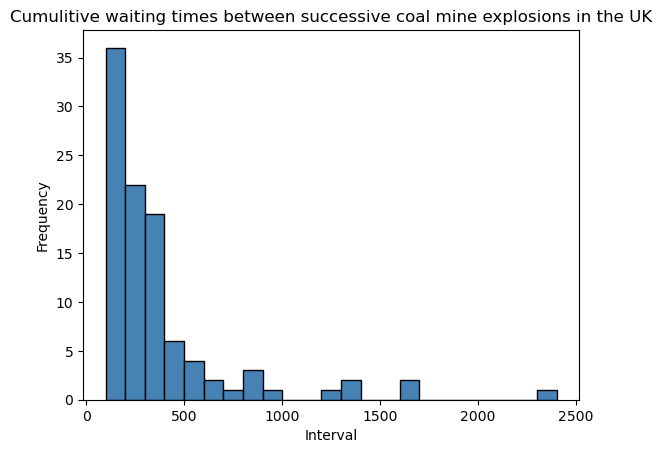

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from csv
df = pd.read_csv(r'C:\Python\OU M248 Data Analysis using Python\Data files\coal.csv')

# print(df.head()) #return the first 5 rows of the dataframe

# Define cutpoints
cutpoints = list(range(100, 2401, 100))
print(cutpoints)

# Plot histogram from Weight change column
plt.hist(df['Interval'], bins=cutpoints, color='steelblue', edgecolor='black', density=False) #Density=False means not to convert to unit area histog

# Add labels and a title
plt.title('Cumulitive waiting times between successive coal mine explosions in the UK')
plt.xlabel('Interval')
plt.ylabel('Frequency')

#### Commentary

Although the histogram of successive coal mine explosions has a close resemblence to an exponential distribution the mean and the standard deviation are not very close which places some doubt about whether the exponential distribution is ideal the observed data.

b) Produce a scatterplot of the number of explosions against time. Do you think that the rate of occurance of coal-mining explosions remained constant over the period of observation?

     Interval   Time  Number
0         157    157       1
1         123    280       2
2           2    282       3
3         124    406       4
4          12    418       5
..        ...    ...     ...
185        18  35241     186
186      1358  36599     187
187      2366  38965     188
188       952  39917     189
189       632  40549     190

[190 rows x 3 columns]


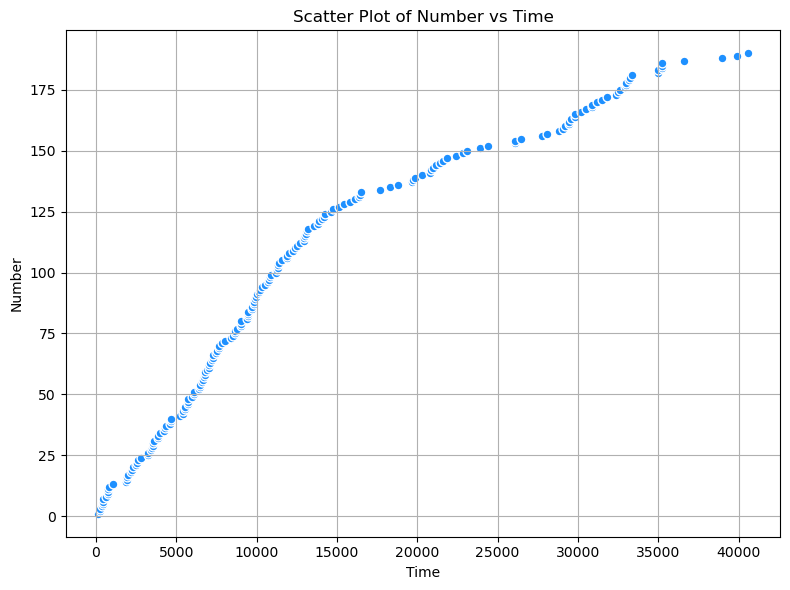

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from csv
df = pd.read_csv(r'C:\Python\OU M248 Data Analysis using Python\Data files\coal.csv')

# Return the first 5 rows of the dataframe
# print(df.head(5))

# Do a cumulative sum of the interval times between coal mine explosions into another column called Time
# running (consecutive) sum of Interval
df["Time"] = df["Interval"].cumsum()

# Do a cumulative count of the interval times between coal mine explosions into another column called Number
# running (consecutive) count of Interval i.e. count the number of rows and then label in a new column from 1 to number of rows
df["Number"] = range(1, len(df) + 1)

# Print the dataframe with the new added columns
print(df)

# Assign columns to X and Y variables
x_col = "Time"
y_col = "Number"

# Plot the scatter
plt.figure(figsize=(8, 6))
plt.scatter(df[x_col], df[y_col], 
            c='dodgerblue',        # marker color
            alpha=1,       # transparency
            edgecolor='w',   # marker border color
            s=40)            # marker size

# Label the axis and title
plt.title(f'Scatter Plot of {y_col} vs {x_col}')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

#### Commentary

It is doubtful whether the rate of coal-mining explosions remained constant of the period. In fact the rate of coal-mining explosions seems to slow down towards the later period which may indicate improved safety measures.

c) Use your answers to parts (a) and (b) to explain whether or not you think that a Poisson process is a suitable model for the occurrences of the coal-mining explosions during the period of observation.

#### Commentary

In order for the Poisson process to be a suitable model for the occurences of coal-mining explosions two conditions have to be met:

1. The rate of occurances of events remains constant
2. The waiting time between two successive events has an exponential distribution

Therefore, on these two bases based on investigations in (a) and (b) the Poisson process is not a suitable model for the occurances of coal-mining explosions within the observed period.

## Computer activity 39: Requests to review

The results of academic research are reported in ‘papers’, which are published in collections called ‘journals’ after undergoing a process of ‘peer review’, that is, after review of their content by a small number of other experts in the field. Such reviews typically give rise either to publication of the paper after it has been revised, or to rejection of the paper as unsuitable for publication in the journal under consideration.

Suppose that the number of times that members of an academic department were asked to perform such reviews in each of 128 consecutive weeks were recorded to produce the data in the worksheet review-requests.csv. (The first entry in the column Requests is for the first week, the second is for the second week, and so on.)

To produce a scatterplot of the cumulative number of requests (Y variables) against time (X variables), notice that the data in worksheet review-requests.csv are slightly different to data in the worksheets so far considered in this chapter (serious-earthquakes.csv and coal.csv). 

In the latter two worksheets, the data were the waiting times between consecutive events, so Partial sum was used to
calculate the times (variable Time) at which the events occurred, and at each of these times the cumulative number of events that had occurred up
to that time increased by one (variable Number). 

Here we have a different situation. In the worksheet review-requests.csv, we are given the number of requests for each of 1, . . . , 128 weeks. So we know that at time 1 (i.e. week 1), 4 events had occurred, at time 2 (i.e. week 2), 4 + 0 = 4 events had occurred, and so on. Therefore create a scatterplot of number of requests against time.

     Requests  Number  Time
0           4       4     1
1           0       4     2
2           0       4     3
3           0       4     4
4           3       7     5
..        ...     ...   ...
123         7     493   124
124         8     501   125
125         4     505   126
126         4     509   127
127         5     514   128

[128 rows x 3 columns]


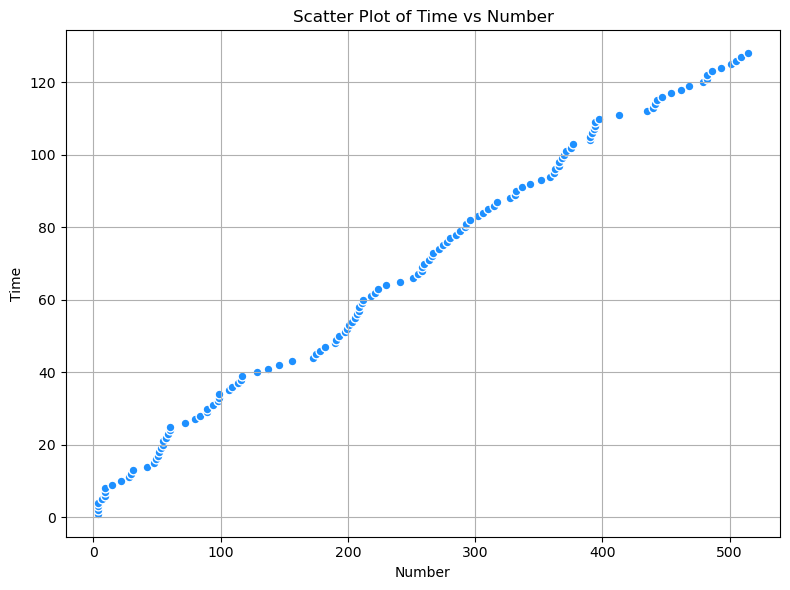

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from csv
df = pd.read_csv(r'C:\Python\OU M248 Data Analysis using Python\Data files\review-requests.csv')

# Return the first 5 rows of the dataframe
# print(df.head(5))

# Do a cumulative sum of the interval times between coal mine explosions into another column called Time
# running (consecutive) sum of Interval
df["Number"] = df["Requests"].cumsum()

# Do a cumulative count of the interval times between coal mine explosions into another column called Number
# running (consecutive) count of Interval i.e. count the number of rows and then label in a new column from 1 to number of rows
df["Time"] = range(1, len(df) + 1)

# Print the dataframe with the new added columns
print(df)

# Assign columns to X and Y variables
x_col = "Number"
y_col = "Time"

# Plot the scatter
plt.figure(figsize=(8, 6))
plt.scatter(df[x_col], df[y_col], 
            c='dodgerblue',        # marker color
            alpha=1,       # transparency
            edgecolor='w',   # marker border color
            s=40)            # marker size

# Label the axis and title
plt.title(f'Scatter Plot of {y_col} vs {x_col}')
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

#### Commentary

The scatter plot shows that the rate of review of the academic papers of the period is constant as can be seen by the approximate straight line.

## Computer activity 40: The number of requests in a week

If a Poisson process is a good model for the receipt of requests to review papers described in Computer activity 39, then the numbers of requests in a week are observations from a Poisson distribution. 

In this activity, you will investigate whether a Poisson distribution is a good model for the data.

a) Find the sample mean and sample standard deviation of the number of review requests in a week. What can you deduce from these values?

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from csv
df = pd.read_csv(r'C:\Python\OU M248 Data Analysis using Python\Data files\review-requests.csv')

# Return the first 5 rows of the dataframe
print(df.head(5))

mean_interval = df["Requests"].mean()
std_interval = df["Requests"].std()
print("")
print("The sample mean of number of review requests in a week: ", round(mean_interval,3))
print("The sample standard deviation of number of review requests in a week: ", round(std_interval,3))
print("The sample variance of number of review requests in a week: ", round((std_interval)**2,3))

   Requests
0         4
1         0
2         0
3         0
4         3

The sample mean of number of review requests in a week:  4.016
The sample standard deviation of number of review requests in a week:  3.808
The sample variance of number of review requests in a week:  14.504


b) Since the numbers of review requests received each week are discrete, a bar chart should be used to get a feel for the distribution of the number of weekly requests.

Text(0, 0.5, 'Frequency')

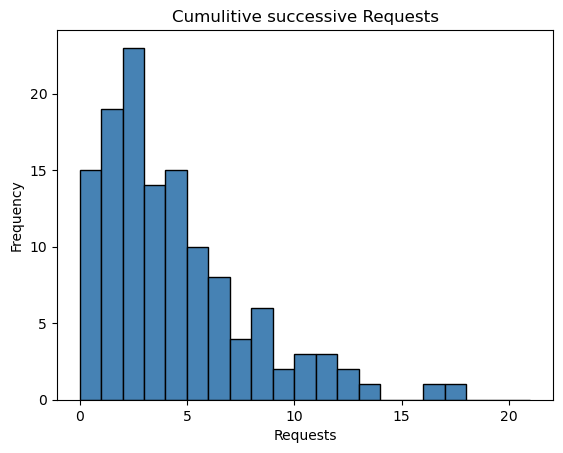

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data from csv
df = pd.read_csv(r'C:\Python\OU M248 Data Analysis using Python\Data files\review-requests.csv')

# Return the first 5 rows of the dataframe
# print(df.head(5))

# Define cutpoints
cutpoints = list(range(0, 22, 1))
# print(cutpoints)

#Density=False means not to convert to unit area histogram
plt.hist(df['Requests'], bins=cutpoints, color='steelblue', edgecolor='black', density=False) 

# Add labels and a title
plt.title('Cumulitive successive Requests')
plt.xlabel('Requests')
plt.ylabel('Frequency')


c) Obtain a diagram of the probability mass function of a Poisson distribution with mean 4.016 (the value of the sample mean)

The Probability Mass Function of a Poisson distribution:

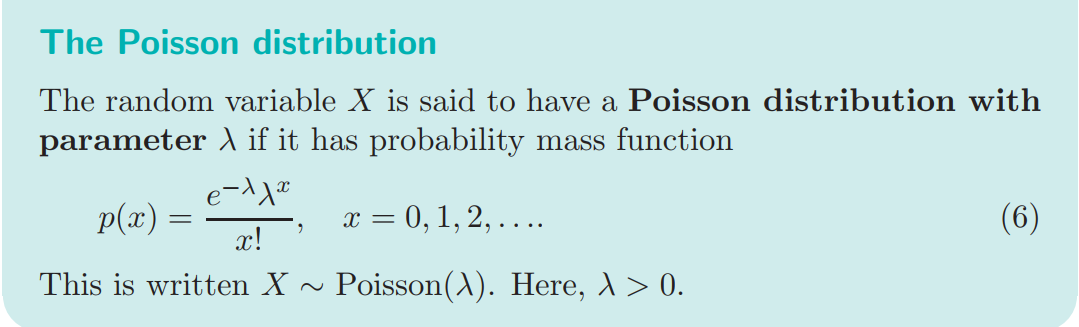

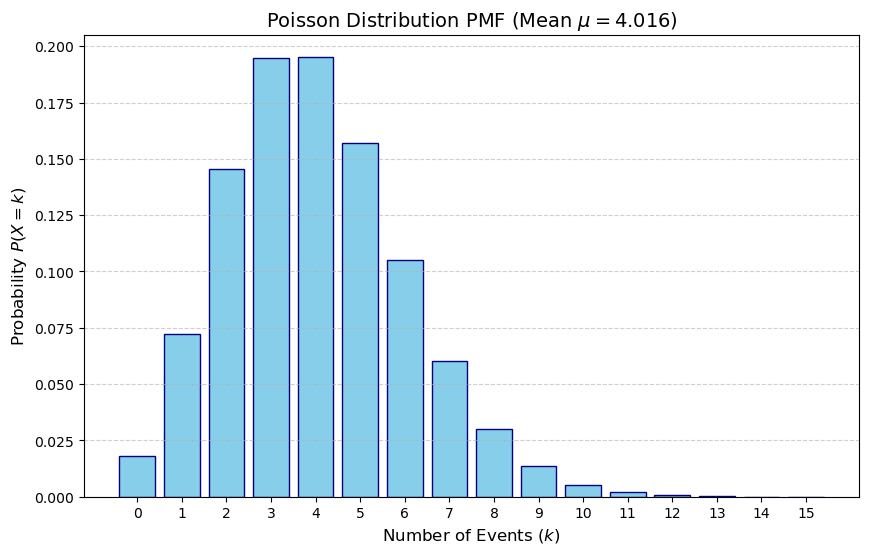

k = 0: P(X = 0) = 0.0180
k = 1: P(X = 1) = 0.0724
k = 2: P(X = 2) = 0.1454
k = 3: P(X = 3) = 0.1946
k = 4: P(X = 4) = 0.1954
k = 5: P(X = 5) = 0.1569
k = 6: P(X = 6) = 0.1050
k = 7: P(X = 7) = 0.0603
k = 8: P(X = 8) = 0.0302
k = 9: P(X = 9) = 0.0135
k = 10: P(X = 10) = 0.0054
k = 11: P(X = 11) = 0.0020
k = 12: P(X = 12) = 0.0007
k = 13: P(X = 13) = 0.0002
k = 14: P(X = 14) = 0.0001
k = 15: P(X = 15) = 0.0000


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parameter for the Poisson distribution
mu = 4.016

# Define the range of possible outcomes (k)
k_values = np.arange(0, 16)

# Calculate the Probability Mass Function (PMF) values
pmf_values = poisson.pmf(k_values, mu)

# Create the plot
plt.figure(figsize=(10, 6))

# width=0.8 to indicate that the data is discrete
plt.bar(k_values, pmf_values, color='skyblue', edgecolor='navy', width=0.8)

# Adding labels and title
plt.title(f'Poisson Distribution PMF (Mean $\mu = {mu}$)', fontsize=14)
plt.xlabel('Number of Events ($k$)', fontsize=12)
plt.ylabel('Probability $P(X = k)$', fontsize=12)

# Ensure every integer k is shown on the x-axis
plt.xticks(k_values)

# Adding a grid for easier reading of the probabilities
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.show()

# Print calculated probabilities for each random variable
for k, p in zip(k_values, pmf_values):
    print(f"k = {k}: P(X = {k}) = {p:.4f}")



#### Commentary

Given that firstly, the sample mean and variance of the number of requests are not equal or even close (a requirement of the Poisson distribution to be useful for modelling the given dataset) it follows that the Poisson distribution is a not a good model for the number of requests observations.

Furthermore, given that the Poisson distribution with parameter 4.016 has a disttribution shape which is different from that of the cummumlative frequency of requests shows that the Poisson distribution is not a good model for this observed dataset.

## Computer activity 41: Serious earthquakes

Suppose that the occurrences of serious earthquakes may be modelled by a Poisson process with rate λ = 67/22 120 per day.

(a) Write down the distribution of the number of serious earthquakes that occur in a typical four-year period. Give the value of the parameter correct to three decimal places.

(b) Taking the approximate value for the mean in a four-year period that you found in part (a) as if it were exact, find each of the following probabilities.<br>

(i) The probability that exactly five serious earthquakes occur in a four-year period.<br>
(ii) The probability that fewer than three serious earthquakes occur in a four-year period.<br>
(iii) The probability that at least eight serious earthquakes occur in a four-year period.<br>

(c) Write down the distribution of the waiting time in days between serious earthquakes. Calculate the mean waiting time to the nearest day.

(d) Taking the approximate value for the mean waiting time that you found in part (c) as if it were exact, find the probability that the gap between successive serious earthquakes.<br>
(i) will be less than 30 days.<br>
(ii) will exceed two years.<br>

*For part a*

In [7]:
lambda_rate = 67 / 22120 #Rate of Poisson process i.e. rate of events occuring per unit time
days_in_4_years = 1461 #Note that a 4 year period will include one leap year of 366 days

# Calculate mu (the average number of occurrences)
lambda_rate_time = round(lambda_rate * days_in_4_years,3) #λt = the parameter (mean) of the Poisson distribution
print(f"{lambda_rate_time=}")
print(f"Hence distribution of # of earthquakes in a four-year period is: X ~ Poisson({lambda_rate_time})")

lambda_rate_time=4.425
Hence distribution of # of earthquakes in a four-year period is: X ~ Poisson(4.425)


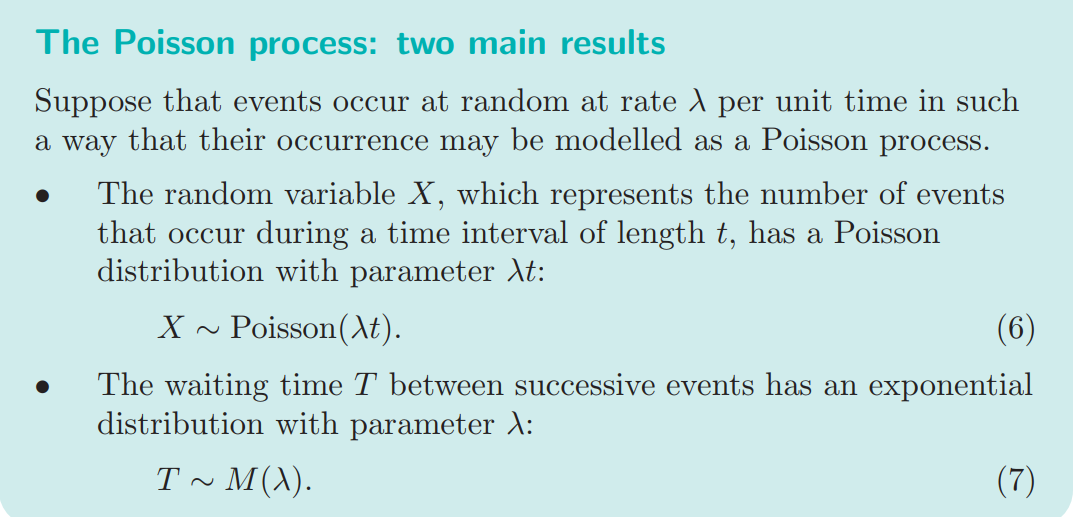

*For part b*

This is based on the Poisson PMF (Probability Mass Function) also mentioned above:
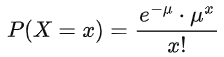

In [8]:
import math

lambda_rate_time = 4.425

print("The probability that exactly five serious earthquakes occur in a four-year period")
p_5 = round((math.exp(-lambda_rate_time) * (lambda_rate_time**5)) / math.factorial(5),3)
print(f"{p_5=}")

print("The probability that fewer than three serious earthquakes occur in a four-year period")
p_fewer_than_3 = round(sum([(math.exp(-lambda_rate_time) * (lambda_rate_time**k)) / math.factorial(k) for k in range(3)]),3)
print(f"{p_fewer_than_3=}")

print("The probability that at least eight serious earthquakes occur in a four-year period.")
p_le_7 = sum([(math.exp(-lambda_rate_time) * (lambda_rate_time**k)) / math.factorial(k) for k in range(8)])
p_at_least_8 = round(1 - p_le_7,3)
print(f"{p_at_least_8=}")

The probability that exactly five serious earthquakes occur in a four-year period
p_5=0.169
The probability that fewer than three serious earthquakes occur in a four-year period
p_fewer_than_3=0.182
The probability that at least eight serious earthquakes occur in a four-year period.
p_at_least_8=0.081


*For part c*

The distribution of the waiting time in days between serious earthquakes is:

$T \sim M(67 / 22120)$

Where $T$ is the waiting time between successive earthquakes which has an exponential distribution with parameter $\lambda$

A random variable with an exponential distribution with parameter $\lambda$ has a mean equal to:

In [17]:
lambda_rate = 67 / 22120
mean = round(1/lambda_rate,3)
print(f'The mean waiting time in days between earthquakes is: {mean}')

The mean waiting time in days between earthquakes is: 330.149


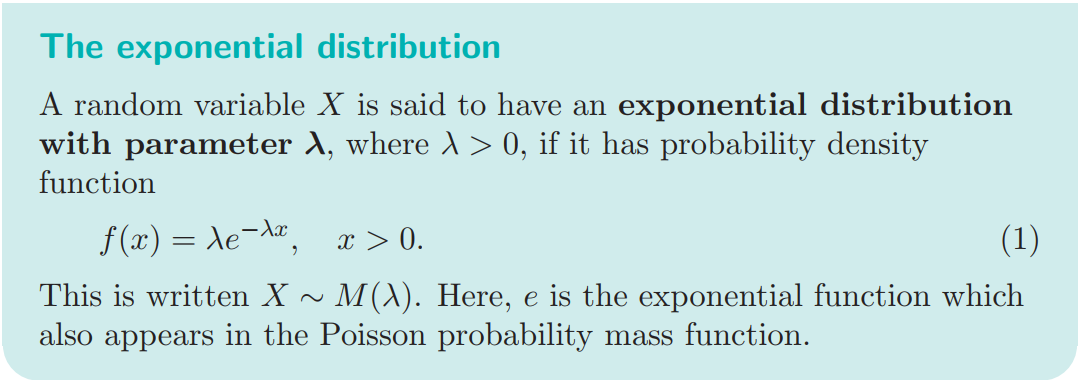

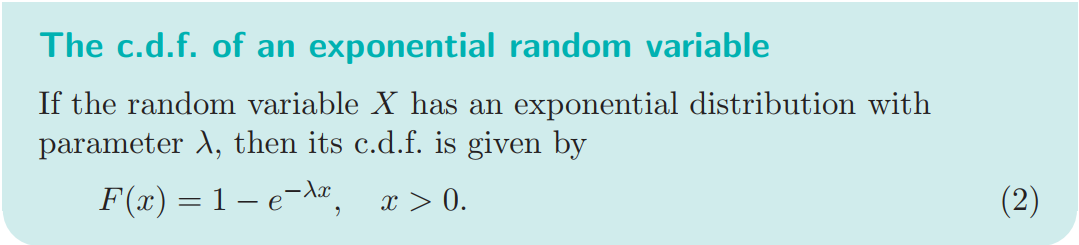

*For part d*

The probability that the gap between successive serious earthquakes will be less than 30 days $P(T < 30) = F(30)$ is:

In [12]:
import math

lambda_rate = 67 / 22120

p_less_30 = round(1 - math.exp(-30 * lambda_rate),4)

print(f"{p_less_30=} or {round(p_less_30*100,4)}%")

p_less_30=0.0869 or 8.69%


The probability that the gap between successive serious earthquakes will exceed two years ($P(T > 730) = 1-(P \leq 730)$ is:

In [2]:
import math

lambda_rate = 67 / 22120

p_exceed_2_years = round(math.exp(-730 * lambda_rate),4)

print(f"{p_exceed_2_years=} or {round(p_exceed_2_years*100,4)}%")

p_exceed_2_years=0.1096 or 10.96%


## Computer activity 42: Emissions of alpha particles

Suppose that emissions of alpha particles may be modelled by a Poisson process with rate λ = 0.517 per second. (This is the estimate for λ obtained from the data.)

**(a)** Write down the distribution of the number of alpha particles emitted in a one-minute period.<br>

**(b)**<br> 
**(i)** Find the probability that exactly 30 particles are emitted in a one-minute period.<br>
**(ii)** Find the probability that fewer than 20 particles are emitted in a one-minute period.<br>
**(iii)** Find the probability that at least 50 particles are emitted in one minute.<br>

**(c)** Write down the probability distribution of the interval between successive emissions of particles.<br>

**(d)**<br> 
**(i)** Find the probability that the interval between successive emissions is less than half a second.<br>
**(ii)** Find the probability that the interval between successive emissions exceeds three seconds.<br>

**For part a**

The distribution of the number of alpha particles emitted in a one-minute period is:

$X ∼ Poisson(0.517*60) = X ∼ Poisson(31.02)$

Where $X$ is a random variable representing the number of alpha particles emitted in a one-minute period and it's parameter is 31.02

**For part b)i)**

The probability that exactly 30 particles are emitted in a one-minute period $P(X=30)$


In [22]:
import math

lambda_rate = 0.517
t = 60
mu = lambda_rate * t

x = 30
p_30 = round((math.exp(-mu) * (mu**x)) / math.factorial(x),4)

print(f"{p_30=} or {p_30*100}%")

p_30=0.0714 or 7.140000000000001%


**For part b)ii)**

The probability that fewer than 20 particles are emitted in a one minute period $P(X < 20) = P(X \leq 19)$.

*Note: Since the Poisson process has no CDF function then the sum of the PMF function as to be used to obtain the required probability i.e.*

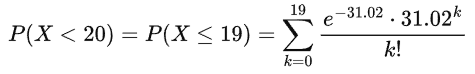

In [1]:
import math

mu = 31.02

p_fewer_than_20 = round(sum([(math.exp(-mu) * (mu**k)) / math.factorial(k) for k in range(20)]),4)

print(f"{p_fewer_than_20 = } or {p_fewer_than_20*100}%")

p_fewer_than_20 = 0.0143 or 1.43%


**For part b)iii)**

The probability that at least 50 (i.e. 50 or more) particles are emitted in one minute can be rephrased as $P(X \geq 50) =1 -P(X \leq 49)$.

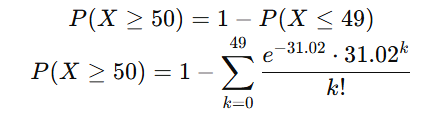

In [18]:
import math

mu = 31.02

p_leq_49 = sum([(math.exp(-mu) * (mu**k)) / math.factorial(k) for k in range(50)])
p_geq_50 = round(1 - p_leq_49,4)

print(f"{p_geq_50 = } or {p_geq_50*100}%")

p_geq_50 = 0.001 or 0.1%


**For part c**

The probability distribution of the interval between successive emissions of particles is:

$T ∼ (0.517)$

Where T is the random variable for the time interval between successive emissions and has an exponential distribution with parameter: $\lambda = 0.517$ 

**For part d)i)**

Using the CDF formula for the exponential distribution with $\lambda = 0.517$ the probability that the interval between successive emissions is less than half a second is:

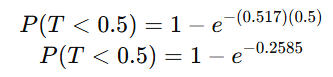

Note that since the time intervals are essentially continous then: $P(T < 0.5) = P(0.5)$

In [33]:
import math

lambda_rate = 0.517

prob_lt_05_s = round(1 - math.exp(-lambda_rate * 0.5),4)

print(f"{prob_lt_05_s=} or {prob_lt_05_s*100}%")

prob_lt_05_s=0.2278 or 22.78%


**For part d)ii)**

Again using the CDF formula for the exponential distribution with $\lambda = 0.517$ the probability that the interval between successive emissions exceeds 3 seconds is:



In [1]:
import math

lambda_rate = 0.517

prob_gt_30_s = round(1-(1 - math.exp(-lambda_rate * 3)),4)

print(f"{prob_gt_30_s=} or {prob_gt_30_s*100}%")

prob_gt_30_s=0.212 or 21.2%


**Explainer: The Poisson Process & The Exponential Distribution**

The Poisson process focuses on how many events happen in a specific amount of time whereas the Exponential distribution focuses on the waiting time between events.

**Example:** How many emails arrive in a day

For example, the probability of how many emails arrive in a day can be modelled by the Poisson process whereas the probability of long you wait for the next email can be modelled by the exponential distribution.

**Example:** How long do you wait for the next email